## Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import LabelEncoder

## Đọc dữ liệu từ file CSV

In [2]:

df = pd.read_csv(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\data\live\sales_dashboard.csv")

df.head()

,order_id,order_purchase_timestamp,price,freight_value,payment_value,order_status,seller_id,customer_unique_id,customer_city,customer_state,product_category_name,Category_VN,product_id
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99,8.72,38.71,delivered,3504c0cb71d7fa48d967e0e4c94d59d9,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,utilidades_domesticas,Đồ gia dụng,87285b34884572647811a353c7ac498a
1,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00,27.20,72.20,delivered,66922902710d126a0e7d26b0e3805106,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,pet_shop,Thú cưng,d0b61bfb1de832b15ba9d266ca96e5b0
2,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90,8.72,28.62,delivered,2c9e548be18521d1c43cde1c582c6de8,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,papelaria,Văn phòng phẩm,65266b2da20d04dbe00c5c2d3bb7859e
3,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,147.90,27.36,175.26,delivered,8581055ce74af1daba164fdbd55a40de,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,automotivo,Phụ tùng ô tô,060cb19345d90064d1015407193c233d
4,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,59.99,15.17,75.16,delivered,16090f2ca825584b5a147ab24aa30c86,932afa1e708222e5821dac9cd5db4cae,nilopolis,RJ,automotivo,Phụ tùng ô tô,4520766ec412348b8d4caa5e8a18c464


## Kiểm tra thông tin dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101469 entries, 0 to 101468
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  101469 non-null  object 
 1   order_purchase_timestamp  101469 non-null  object 
 2   price                     101469 non-null  float64
 3   freight_value             101469 non-null  float64
 4   payment_value             101469 non-null  float64
 5   order_status              101469 non-null  object 
 6   seller_id                 101469 non-null  object 
 7   customer_unique_id        101469 non-null  object 
 8   customer_city             101469 non-null  object 
 9   customer_state            101469 non-null  object 
 10  product_category_name     101469 non-null  object 
 11  Category_VN               101469 non-null  object 
 12  product_id                101469 non-null  object 
dtypes: float64(3), object(10)
memory usage: 10.1

## Thống kê mô tả dữ liệu

In [4]:
df.describe()

,price,freight_value,payment_value
count,101469.000000,101469.000000,101469.000000
mean,120.068787,19.869711,179.993615
std,181.656081,15.480839,274.387174
min,0.850000,0.000000,10.070000
25%,39.900000,13.080000,65.710000
50%,74.990000,16.200000,114.490000
75%,134.900000,21.060000,195.360000
max,6735.000000,409.680000,13664.080000


## Thống kê và xóa các dòng dữ liệu thiếu

In [5]:
df.isnull().sum()

order_id                    0
order_purchase_timestamp    0
price                       0
freight_value               0
payment_value               0
order_status                0
seller_id                   0
customer_unique_id          0
customer_city               0
customer_state              0
product_category_name       0
Category_VN                 0
product_id                  0
dtype: int64

In [6]:
df = df.dropna()

## Chuyển cột thời gian sang dạng datetime

In [7]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [8]:
## 👉 GỘP THEO NGÀY (QUAN TRỌNG NHẤT)

In [9]:
df['date'] = df['order_purchase_timestamp'].dt.date

df_daily = df.groupby('date')['payment_value'].sum().reset_index()
df_daily.columns = ['date','revenue']

df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily = df_daily.sort_values('date')


In [10]:
## FEATURE ENGINEERING

In [11]:
df_daily['dayofweek'] = df_daily['date'].dt.dayofweek
df_daily['month'] = df_daily['date'].dt.month

df_daily['lag1'] = df_daily['revenue'].shift(1)
df_daily['lag7'] = df_daily['revenue'].shift(7)
df_daily['lag14'] = df_daily['revenue'].shift(14)

df_daily['rolling7'] = df_daily['revenue'].rolling(7).mean()
df_daily['rolling14'] = df_daily['revenue'].rolling(14).mean()

df_daily = df_daily.dropna()

In [12]:
## TRAIN TEST SPLIT (TIME SERIES)

In [13]:
test_days = 30

train = df_daily.iloc[:-test_days]
test = df_daily.iloc[-test_days:]

X_train = train.drop(columns=['revenue','date'])
y_train = train['revenue']

X_test = test.drop(columns=['revenue','date'])
y_test = test['revenue']

## Bắt đầu huấn luyện mô hình

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

## Dự đoán dữ liệu test

In [15]:
y_pred_lr = lr.predict(X_test)

##  EVALUATION

In [16]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return round(mae,2), round(rmse,2)

mae_lr, rmse_lr = evaluate(y_test, y_pred_lr)

print("📊 EVALUATION:")
print("Linear - MAE:", mae_lr, "| RMSE:", rmse_lr)


📊 EVALUATION:
Linear - MAE: 8202.56 | RMSE: 10801.7


In [17]:
##  VISUALIZE

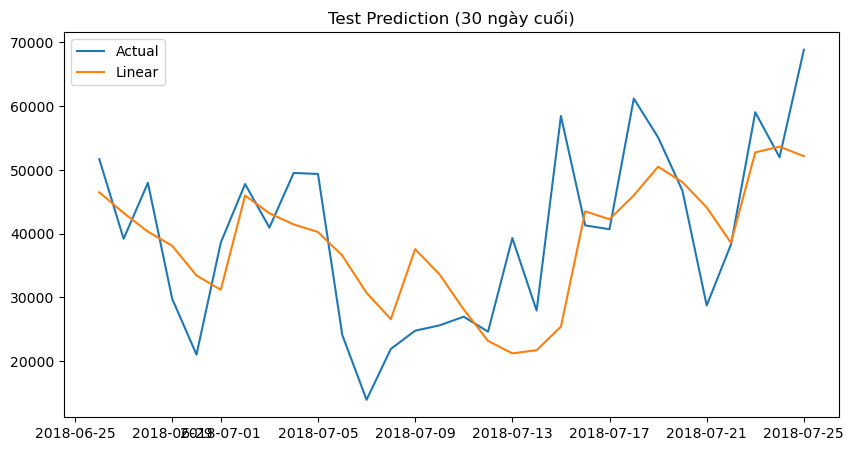

In [18]:
plt.figure(figsize=(10,5))
plt.plot(test['date'], y_test, label='Actual')
plt.plot(test['date'], y_pred_lr, label='Linear')

plt.legend()
plt.title("Test Prediction (30 ngày cuối)")
plt.show()

In [19]:
## TRAIN LẠI FULL DATA


In [20]:
X_full = df_daily.drop(columns=['revenue','date'])
y_full = df_daily['revenue']

lr_final = LinearRegression()
lr_final.fit(X_full, y_full)



LinearRegression()

In [21]:
## FORECAST FUTURE (QUAN TRỌNG)

In [24]:
future_days = 30
future_preds_lr = []

df_future = df_daily.copy()

FEATURES = [
    'dayofweek','month',
    'lag1','lag7','lag14',
    'rolling7','rolling14'
]

for i in range(future_days):
    
    last_row = df_future.iloc[-1:].copy()
    
    # 👉 ngày tiếp theo
    next_date = last_row['date'].values[0] + np.timedelta64(1, 'D')
    
    new_row = pd.DataFrame({'date':[next_date]})
    
    # ===== TIME FEATURE =====
    new_row['dayofweek'] = pd.to_datetime(new_row['date']).dt.dayofweek
    new_row['month'] = pd.to_datetime(new_row['date']).dt.month
    
    # ===== LAG =====
    new_row['lag1'] = df_future['revenue'].iloc[-1]
    new_row['lag7'] = df_future['revenue'].iloc[-7]
    new_row['lag14'] = df_future['revenue'].iloc[-14]
    
    # ===== ROLLING =====
    new_row['rolling7'] = df_future['revenue'].iloc[-7:].mean()
    new_row['rolling14'] = df_future['revenue'].iloc[-14:].mean()
    
    # ===== ĐẢM BẢO ĐÚNG FEATURE =====
    X_new = new_row[FEATURES]
    
    # ===== PREDICT =====
    pred_lr = lr_final.predict(X_new)[0]
    
    # 👉 GÁN KẾT QUẢ ĐÚNG MODEL
    new_row['revenue'] = pred_lr   # ✅ FIX QUAN TRỌNG
    
    # append vào future
    df_future = pd.concat([df_future, new_row], ignore_index=True)
    
    future_preds_lr.append(pred_lr)

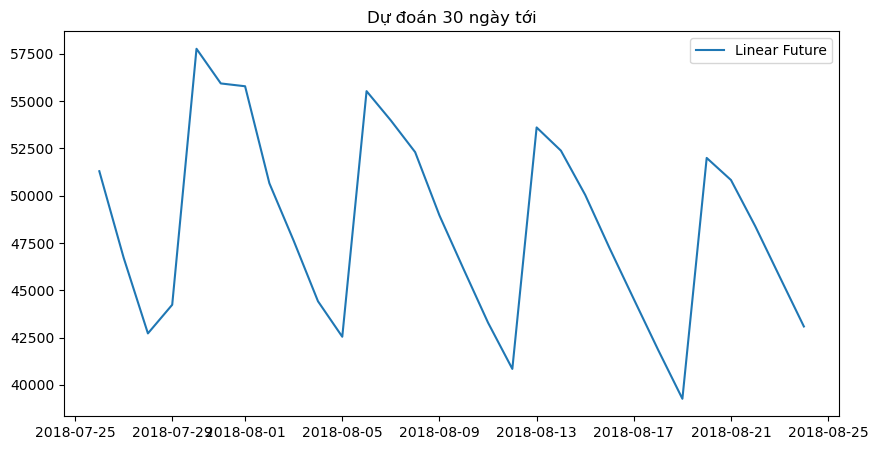

In [25]:
future_dates = df_future['date'].iloc[-future_days:]

plt.figure(figsize=(10,5))
plt.plot(future_dates, future_preds_lr, label='Linear Future')
plt.legend()
plt.title("Dự đoán 30 ngày tới")
plt.show()

## Lưu model vào file pkl

In [26]:
import pickle


with open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\linear_model.pkl", "wb") as f:
    pickle.dump(lr, f)